In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
RAW_DIR = Path(r"C:\Users\khush\idx files")
REPORTS_DIR = Path(r"C:\Users\khush\Desktop\IDX-Exchange\Reports")

sold = pd.read_csv(RAW_DIR / "sold_combined.csv", low_memory=False)
listings = pd.read_csv(RAW_DIR / "listings_combined.csv", low_memory=False)

print("Sold shape:", sold.shape)
print("Listings shape:", listings.shape)

Sold shape: (448253, 82)
Listings shape: (607724, 84)


In [5]:
CORE_FIELDS = {
    'ClosePrice', 'ListPrice', 'OriginalListPrice',
    'LivingArea', 'LotSizeAcres', 'BedroomsTotal', 'BathroomsTotalInteger',
    'DaysOnMarket', 'YearBuilt', 'PropertyType', 'PropertySubType',
    'CountyOrParish', 'City', 'PostalCode', 'Latitude', 'Longitude',
    'CloseDate', 'ListingContractDate', 'PurchaseContractDate',
    'ContractStatusChangeDate', 'ListingKey', 'ListingId'
}

METADATA_FIELDS = {
    'ListAgentFirstName', 'ListAgentLastName', 'ListAgentFullName', 'ListAgentEmail',
    'CoListAgentFirstName', 'CoListAgentLastName',
    'BuyerAgentFirstName', 'BuyerAgentLastName', 'BuyerAgentMlsId',
    'CoBuyerAgentFirstName', 'ListOfficeName', 'BuyerOfficeName',
    'CoListOfficeName', 'BuyerOfficeAOR', 'BuyerAgentAOR', 'ListAgentAOR',
    'OriginatingSystemName', 'OriginatingSystemSubName',
    'ListingKeyNumeric', 'MlsStatus', 'StreetNumberNumeric'
}

# Classify each column
def classify_fields(columns):
    rows = []
    for col in columns:
        if col in METADATA_FIELDS:
            category = 'metadata'
        elif col in CORE_FIELDS:
            category = 'core'
        else:
            category = 'market_analysis_other'
        rows.append({'column': col, 'category': category})
    return pd.DataFrame(rows)

field_classification = classify_fields(sold.columns)
print(field_classification)

                          column               category
0                       Flooring  market_analysis_other
1                         ViewYN  market_analysis_other
2                   WaterfrontYN  market_analysis_other
3                     BasementYN  market_analysis_other
4                  PoolPrivateYN  market_analysis_other
..                           ...                    ...
77  MiddleOrJuniorSchoolDistrict  market_analysis_other
78                 BuyerAgentAOR               metadata
79                  ListAgentAOR               metadata
80         OriginatingSystemName               metadata
81      OriginatingSystemSubName               metadata

[82 rows x 2 columns]


In [7]:
#review column data types
print(sold.dtypes.value_counts())
print(listings.dtypes.value_counts())
#some date values are stored as string instead of int/date, which may make it hard to sort by date or group
#7 object columns - mb mixed types

str        43
float64    29
object      7
int64       3
Name: count, dtype: int64
str        44
float64    33
int64       4
object      3
Name: count, dtype: int64


In [8]:
#identifying high-missing columns + Calculate missing counts and percentages per column - sold
missing_sold = sold.isnull().sum()
missing_pct_sold = (missing_sold / len(sold)) * 100
missing_summary_sold = pd.DataFrame({
    'missing_count': missing_sold,
    'missing_pct': missing_pct_sold
}).sort_values('missing_pct', ascending = False)

print(missing_summary_sold)

                          missing_count  missing_pct
TaxAnnualAmount                  448253        100.0
AboveGradeFinishedArea           448253        100.0
TaxYear                          448253        100.0
ElementarySchoolDistrict         448253        100.0
CoveredSpaces                    448253        100.0
...                                 ...          ...
MlsStatus                             0          0.0
ListOfficeName                        0          0.0
DaysOnMarket                          0          0.0
CountyOrParish                        0          0.0
ListingKeyNumeric                     0          0.0

[82 rows x 2 columns]


In [10]:
# flag columns with ?90% missing values - sold

high_missing_sold = missing_summary_sold[missing_summary_sold['missing_pct'] > 90]


# Missing value analysis - Listings
missing_listings = listings.isnull().sum()
missing_pct_listings = (missing_listings / len(listings)) * 100
missing_summary_listings = pd.DataFrame({
    'missing_count': missing_listings,
    'missing_pct': missing_pct_listings
}).sort_values('missing_pct', ascending=False)

print(missing_summary_listings)

                          missing_count  missing_pct
TaxYear                          607724        100.0
TaxAnnualAmount                  607724        100.0
AboveGradeFinishedArea           607724        100.0
FireplacesTotal                  607724        100.0
ElementarySchoolDistrict         607724        100.0
...                                 ...          ...
PropertyType.1                        0          0.0
ListingKeyNumeric                     0          0.0
MlsStatus                             0          0.0
ListPrice.1                           0          0.0
ListingContractDate                   0          0.0

[84 rows x 2 columns]


In [11]:
# Flag columns with >90% missing (Listings)
high_missing_listings = missing_summary_listings[missing_summary_listings['missing_pct'] > 90]
print("Columns with >90% missing (Listings):")
print(high_missing_listings)

Columns with >90% missing (Listings):
                              missing_count  missing_pct
TaxYear                              607724   100.000000
TaxAnnualAmount                      607724   100.000000
AboveGradeFinishedArea               607724   100.000000
FireplacesTotal                      607724   100.000000
ElementarySchoolDistrict             607724   100.000000
BusinessType                         607724   100.000000
CoveredSpaces                        607724   100.000000
MiddleOrJuniorSchoolDistrict         607724   100.000000
BelowGradeFinishedArea               604202    99.420461
CoBuyerAgentFirstName                590134    97.105594
BuilderName                          579736    95.394620
LotSizeDimensions                    575922    94.767032
BuildingAreaTotal                    553947    91.151082


Decide which columns to drop vs. retain (keep core fields even if partially missing)

- will drop 100% empty fields since it's useless like TaxAnnualAmmount
#will keep key features like WaterfrontYN, BasementYN, BelowGradeFinishedArea, BuilderName
- LotSizeDimensions not critical, BuildingAreaTotal similar to LivingArea, so redundant, ad CoBuyerAgentFirstName can be dropped


In [13]:
# Numeric distribution summary
numeric_cols = ['ClosePrice', 'ListPrice', 'OriginalListPrice', 'LivingArea',
                'LotSizeAcres', 'BedroomsTotal', 'BathroomsTotalInteger', 
                'DaysOnMarket', 'YearBuilt']

distribution_summary = sold[numeric_cols].describe(percentiles=[.05, .25, .5, .75, .95])
print("\nNumeric distribution summary:")
print(distribution_summary)


Numeric distribution summary:
         ClosePrice     ListPrice  OriginalListPrice    LivingArea  \
count  4.482490e+05  4.482530e+05       4.474260e+05  4.479990e+05   
mean   1.183711e+06  1.143209e+06       1.228306e+06  1.904183e+03   
std    5.562462e+06  1.363551e+06       6.729387e+06  2.544772e+04   
min    0.000000e+00  5.250000e+02       0.000000e+00  0.000000e+00   
5%     3.400000e+05  3.450000e+05       3.499000e+05  8.400000e+02   
25%    5.750000e+05  5.780000e+05       5.850000e+05  1.248000e+03   
50%    8.250000e+05  8.190000e+05       8.290000e+05  1.646000e+03   
75%    1.300000e+06  1.295000e+06       1.299000e+06  2.224000e+03   
95%    2.854717e+06  2.875000e+06       2.900000e+06  3.563100e+03   
max    9.895000e+08  1.375000e+08       1.390000e+09  1.702132e+07   

       LotSizeAcres  BedroomsTotal  BathroomsTotalInteger   DaysOnMarket  \
count  4.134540e+05  448241.000000          448183.000000  448253.000000   
mean   6.218619e+01       3.205115            

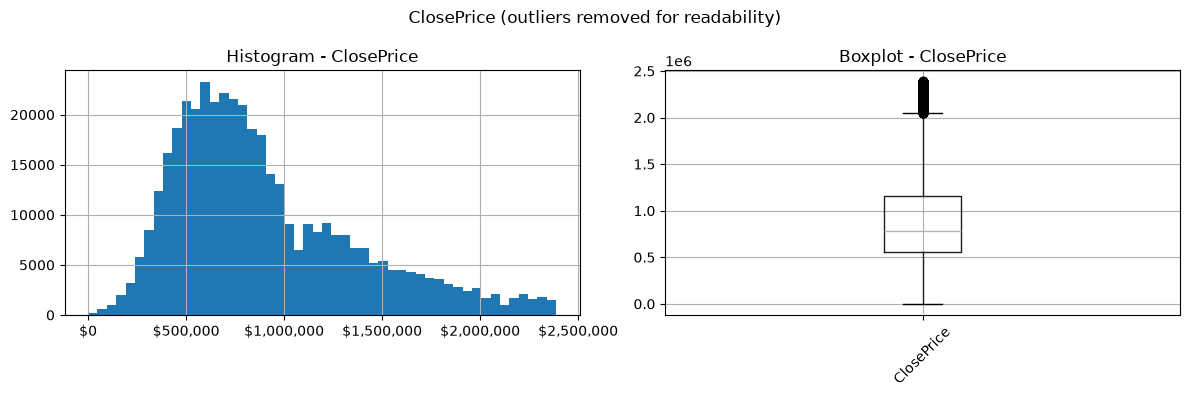

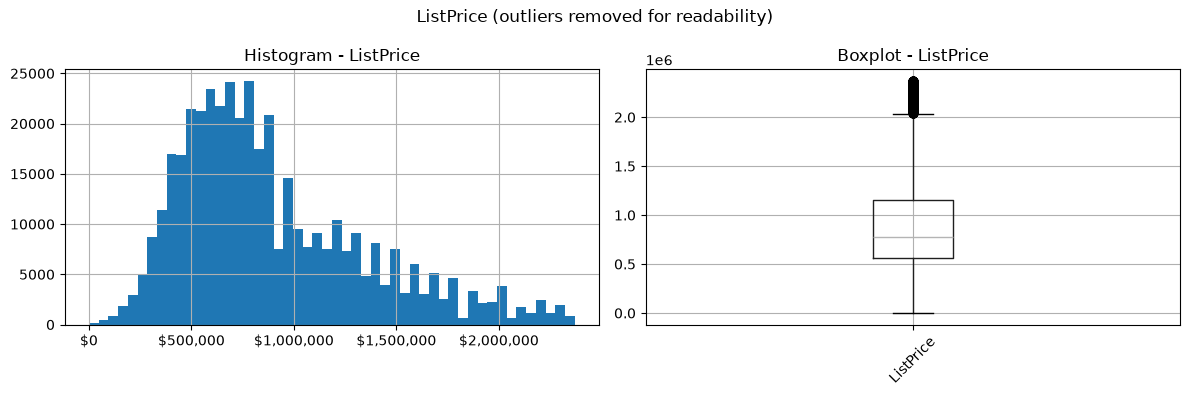

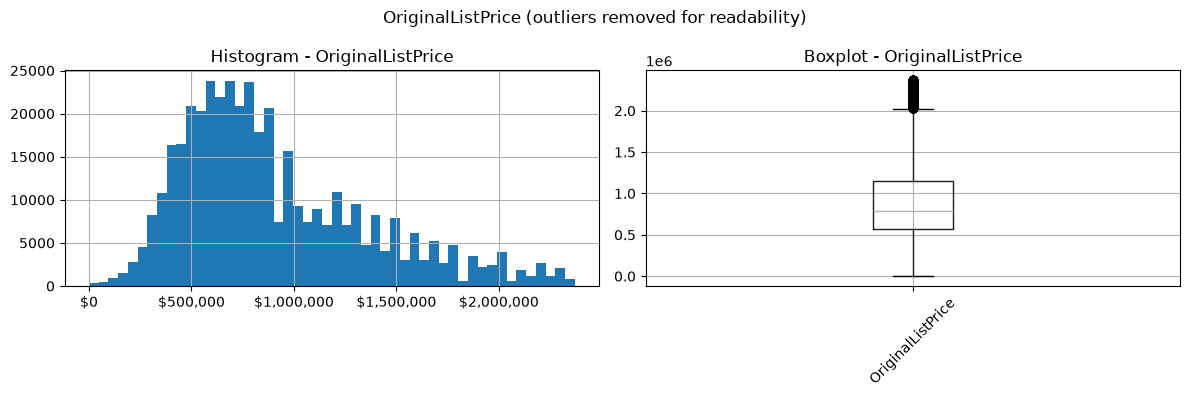

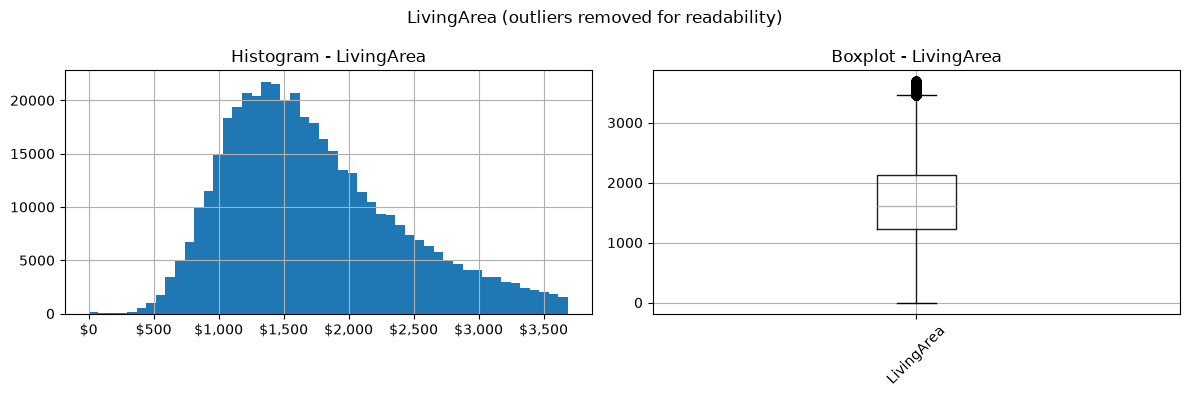

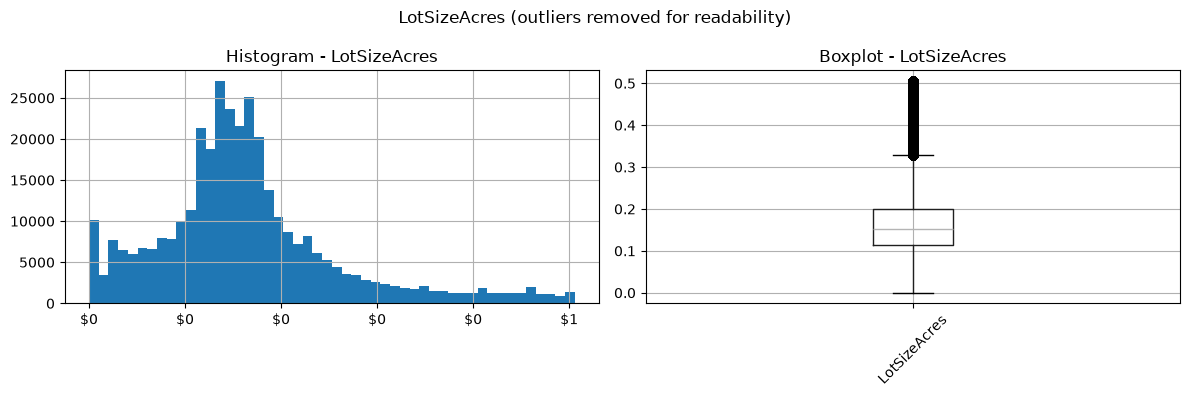

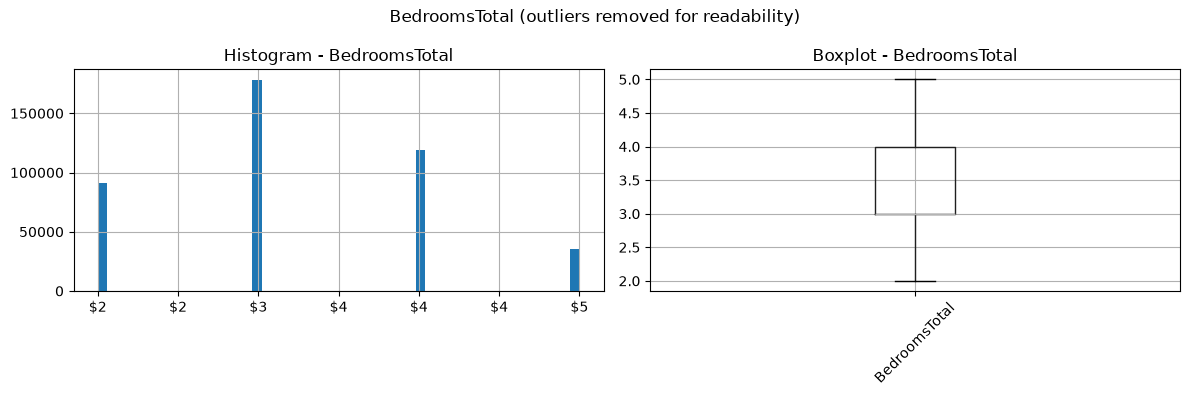

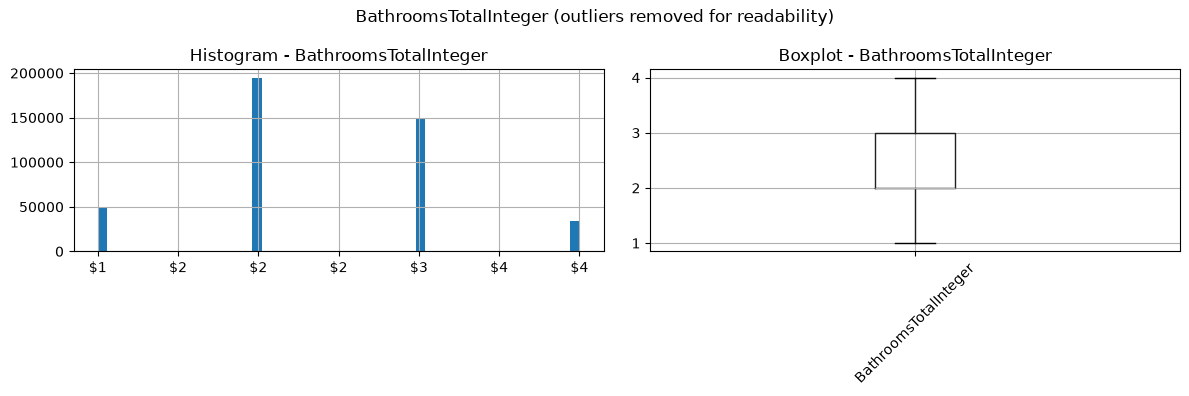

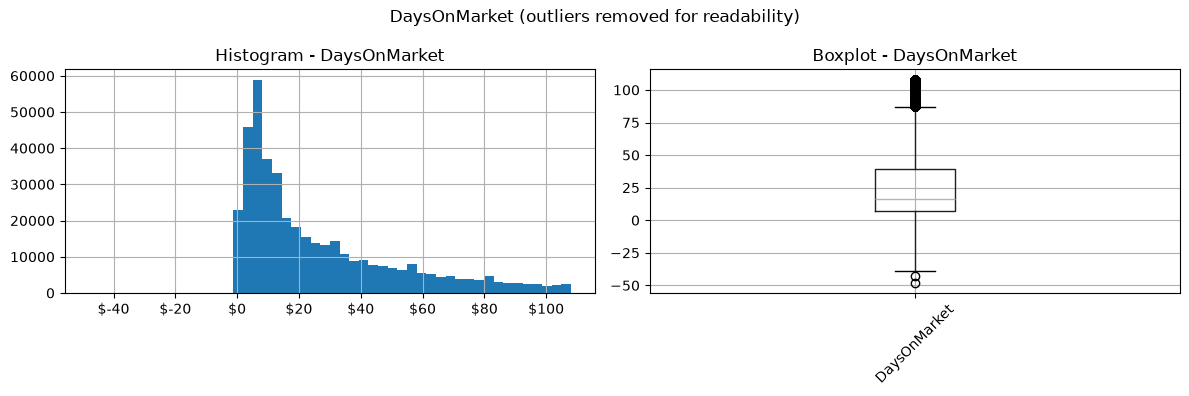

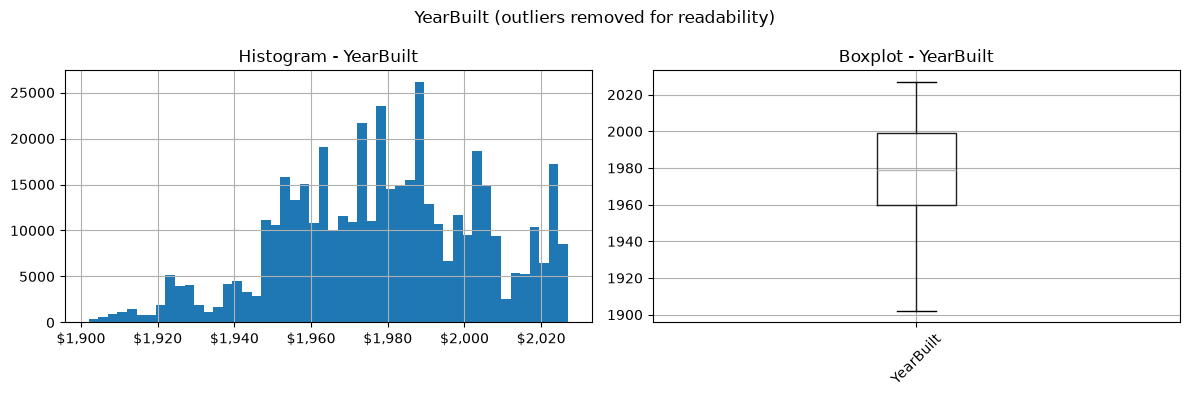

In [16]:
for col in numeric_cols:
    series = sold[col].dropna()
    
    # Filter outliers using IQR for cleaner plots
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    filtered = series[(series >= q1 - 1.5*iqr) & (series <= q3 + 1.5*iqr)]
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    filtered.hist(bins=50, ax=ax1)
    ax1.set_title(f'Histogram - {col}')
    
    filtered.to_frame().boxplot(ax=ax2)
    ax2.set_title(f'Boxplot - {col}')

    ax1.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
    plt.xticks(rotation=45)
    
    plt.suptitle(f'{col} (outliers removed for readability)')
    plt.tight_layout()
    plt.show()

**EDA QUESTIONS**

*1. Residential vs. other property type share*

Dataset was filtered to Residential only in Week 1.

After filtering: 448253 Residential sold records (100% of combined dataset)

Non-residential records were removed during Week 1 aggregation.

Before filter: 640,526 total sold rows -> 430,716 Residential (67%)

In [ ]:
#2. What are the median and average close prices?
print("Median close price:", sold['ClosePrice'].median()) #825,000
print("Average close price:", sold['ClosePrice'].mean()) #1,180,000

Median close price: 825000.0
Average close price: 1183711.1399838037


In [18]:
#3. What does the Days on Market distribution look like?
print(sold['DaysOnMarket'].describe())
#The days on market distribution looks heavily right-skewed, so most homes sell fast but some drag the mean up to 37 days
#Max could be data error and min is -288 days, so we need to clean this out

count    448253.000000
mean         37.326675
std          53.628852
min        -288.000000
25%           8.000000
50%          18.000000
75%          48.000000
max       12430.000000
Name: DaysOnMarket, dtype: float64


In [22]:
#What percentage of homes sold above vs. below list price?
sold['priceDiff'] = sold['ClosePrice'] - sold['ListPrice']
above = (sold['priceDiff'] > 0).sum()
below = (sold['priceDiff'] < 0).sum()
equal = (sold['priceDiff'] == 0).sum()
total = len(sold)

print("Sold above:")
print(above/total * 100) #40.036
print("sold below")
print(below/total*100) #42.58
print("sold at")
print(equal/total*100) #17.38

Sold above:
40.036318775334465
sold below
42.580194666851085
sold at
17.38259420461213


In [23]:
#Which counties have the highest median prices?
country_median = sold.groupby('CountyOrParish')['ClosePrice'].median().sort_values(ascending=False)
print(country_median.head(10))

print(sold[sold['CountyOrParish'] == 'Del Norte']['ClosePrice'].count())

# Note: Del Norte county only has 1 sale, so its median is not representative
# In future analysis, filter to counties with sufficient sample size (e.g. >= 50 sales)



CountyOrParish
Del Norte        2485000.0
San Mateo        1700000.0
Santa Clara      1600000.0
San Francisco    1200000.0
Santa Cruz       1197000.0
Orange           1180000.0
Marin            1172500.0
Alameda          1140000.0
Alpine           1100000.0
Other County     1100000.0
Name: ClosePrice, dtype: float64
1


In [24]:
#Are there any date consistency issues (e.g., close date before listing date)?
# 5. Date consistency checks
print("\nSample date values:")
print(sold[['ListingContractDate', 'PurchaseContractDate', 'CloseDate']].head(10))

# Check for null dates
print("\nMissing dates (Sold):")
print(sold[['ListingContractDate', 'PurchaseContractDate', 'CloseDate']].isnull().sum())
# Date format appears consistent (YYYY-MM-DD) but dates are still strings
# Visible issues: some CloseDate precedes PurchaseContractDate (e.g. rows 5, 9)
# Full date consistency flags (listing_after_close_flag, purchase_after_close_flag, 
# negative_timeline_flag) will be created in Weeks 4-5 after converting to datetime
# Missing: ListingContractDate=1, PurchaseContractDate=196, CloseDate=0




Sample date values:
  ListingContractDate PurchaseContractDate   CloseDate
0          2021-10-06           2023-11-22  2024-01-26
1          2021-03-08           2021-06-30  2024-01-05
2          2021-03-08           2021-11-18  2024-01-05
3          2023-11-15           2023-11-15  2024-01-02
4          2023-11-17           2023-12-19  2024-01-22
5          2024-01-31           2024-03-04  2024-01-31
6          2024-01-09           2024-01-10  2024-01-31
7          2024-01-12           2024-01-13  2024-01-30
8          2023-12-07           2024-01-10  2024-01-16
9          2024-01-31           2024-02-05  2024-01-31

Missing dates (Sold):
ListingContractDate       1
PurchaseContractDate    197
CloseDate                 0
dtype: int64
